# RA3 — Inter-trial intervals and state-transition structure

**Reviewer comment IDs: R1-C3, R2-4, R2-9.**

**Data**: same canonical 80-20 2-ABT snapshot as Fig 6/Fig 7/RA1, classified
with the manuscript's own `classify_state_v7` taxonomy (identical
thresholds/config as Fig 7/Fig 8/RA1 — no alternate taxonomy, no retuning).
ITI is computed directly from the snapshot's own `AbsoluteTrialStartTime`
column (`src/behavior_metrics/iti_analysis.py::compute_iti`, the same
function Fig 1 uses), with the same implausible-ITI ceiling Fig 1 already
established (`fig1.max_iti`).

**Structure**:
1. Reconstruct features, classify with `classify_state_v7`, compute ITI.
2. ITI distribution by behavioral state; post-win vs. post-loss ITI within state.
3. ITI on trials immediately preceding a state transition vs. within-state trials.
4. Outcome sequences (last 1–3 trials) preceding each transition type.
5. Per-animal transition matrices + a hierarchical (animal-cluster) bootstrap estimate of pooled transition-probability uncertainty.
6. RESPONSE MANIFEST.


In [1]:
import os
import sys
import json
import functools

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import SVG, display

sys.path.insert(0, os.path.abspath("../.."))

from src.io.load_snapshots import load_config, load_snapshot
from src.features import state_features, history_encoding
from src.behavior_metrics import state_classifier, state_taxonomy_v7 as sx7, iti_analysis
from src.plotting.style import apply_style
from src.plotting import ra3 as plotting

config = load_config()
apply_style(config)
cfg = config["ra3"]
st_cfg = config["state_taxonomy"]
fig1_cfg = config["fig1"]

FIG_DIR = os.path.join("../..", config["paths"]["figures_out"], "reviewer_analyses", "RA3")
SUPP_DIR = os.path.join(FIG_DIR, "supp_candidates")
os.makedirs(SUPP_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("../..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "RA3 -- ITI by state, ITI preceding transitions, transition-type history, per-animal transition matrices",
            "figures": {}}


def show(path):
    display(SVG(path))
STATES_NON_ADAPTING = state_classifier.STATES_V7_NON_ADAPTING


## 1. Reconstruct state features, classify with `classify_state_v7`, compute ITI

In [2]:
df_raw = load_snapshot(config, st_cfg["input_files"]["reversal_80_20_2abt"])
df = state_features.build_state_features_df(
    df_raw, st_cfg["task_type"], st_cfg["prob_condition"], st_cfg["rolling_window"]
)
block_labels = state_classifier.label_block_adaptation_speed(
    df, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"]
)
adaptation_labels = state_classifier.compute_adaptation_labels(
    df, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"], block_labels=block_labels
)
classify = functools.partial(
    state_classifier.classify_state_v7, adaptation_labels=adaptation_labels, config=st_cfg["classify_updated"]
)
df["Behavioral_State"] = df.apply(classify, axis=1)
print(f"{len(df):,} trials, {df['Session_ID'].nunique()} sessions, {df['Animal_Name'].nunique()} animals")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

df_timing = iti_analysis.compute_iti(df)
df_timing = iti_analysis.filter_iti(df_timing, fig1_cfg["max_iti"])
print(f"{len(df_timing):,} trials with a valid ITI (<= {fig1_cfg['max_iti']}s), "
      f"{len(df) - len(df_timing):,} dropped (first-trial-of-session or implausible)")
manifest["n_trials_with_valid_iti"] = int(len(df_timing))


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


36,673 trials, 100 sessions, 5 animals
36,559 trials with a valid ITI (<= 1000s), 114 dropped (first-trial-of-session or implausible)


## 2. ITI distribution by behavioral state, and post-win vs. post-loss ITI within state

       Behavioral_State     mean     sem  n
0       Adapting (fast)    8.924   0.893  5
1       Adapting (slow)   10.345   1.755  5
2  Directed Exploration   12.160   1.746  5
3               Exploit    6.800   0.979  5
4             Left Bias   10.436   2.897  5
5    Random Exploration   12.127   2.244  5
6            Right Bias   15.907   2.358  5
7               Unknown  124.599  51.830  5

       Behavioral_State  post_win_mean  post_loss_mean  n_animals  \
0       Adapting (fast)         9.3793          7.7743          5   
1       Adapting (slow)         9.6605         10.9249          5   
2  Directed Exploration        12.6102         11.5905          5   
3               Exploit         6.7473          6.6388          5   
4             Left Bias        12.8302         10.0224          5   
5    Random Exploration        16.5219         12.2562          5   
6            Right Bias        20.0592         13.9439          5   

   wilcoxon_stat  wilcoxon_p  
0            4.0   

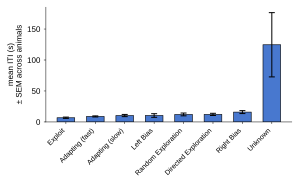

In [3]:
iti_state_result = iti_analysis.iti_by_state(df_timing, state_col="Behavioral_State")
print(iti_state_result["state_summary"].round(3))
print()
print(iti_state_result["post_win_vs_post_loss_by_state"].round(4))

manifest["iti_by_state"] = {
    "state_summary": iti_state_result["state_summary"].to_dict(orient="records"),
    "post_win_vs_post_loss": iti_state_result["post_win_vs_post_loss_by_state"].to_dict(orient="records"),
}

out_iti_fig = os.path.join(SUPP_DIR, "RA3_iti_by_state.svg")
plotting.plot_iti_by_state(manifest["iti_by_state"]["state_summary"], out_iti_fig)
show(out_iti_fig)
manifest["figures"]["iti_by_state"] = {"path": out_iti_fig, "tag": "PAPER"}


## 3. ITI immediately preceding a state transition vs. within-state trials

Preceding a transition: 10.082s  (n_animals=5)
Within state (no transition next): 9.135s
Wilcoxon: stat=1.0  p=0.125


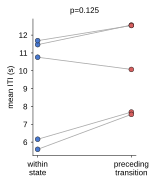

In [4]:
iti_transition_result = iti_analysis.iti_preceding_transitions(df_timing, state_col="Behavioral_State")
print(f"Preceding a transition: {iti_transition_result['preceding_transition_mean']:.3f}s  "
      f"(n_animals={iti_transition_result['n_animals']})")
print(f"Within state (no transition next): {iti_transition_result['within_state_mean']:.3f}s")
print(f"Wilcoxon: stat={iti_transition_result['wilcoxon_stat']}  p={iti_transition_result['wilcoxon_p']}")

manifest["iti_preceding_transitions"] = {
    "preceding_transition_mean": iti_transition_result["preceding_transition_mean"],
    "within_state_mean": iti_transition_result["within_state_mean"],
    "n_animals": iti_transition_result["n_animals"],
    "wilcoxon_stat": iti_transition_result["wilcoxon_stat"],
    "wilcoxon_p": iti_transition_result["wilcoxon_p"],
}

out_preceding_fig = os.path.join(FIG_DIR, "RA3_iti_preceding_transitions.svg")
plotting.plot_iti_preceding_transitions(
    iti_transition_result["preceding_transition_mean"], iti_transition_result["within_state_mean"],
    iti_transition_result["animal_level"], iti_transition_result["wilcoxon_p"], out_preceding_fig,
)
show(out_preceding_fig)
manifest["figures"]["iti_preceding_transitions"] = {"path": out_preceding_fig, "tag": "LETTER-ONLY"}


## 4. Outcome sequences (last 1–3 trials) preceding each transition type

Reuses `history_encoding.add_history_cols_marmoset` unchanged (its
`reward_seq` at trial *t* already encodes the trailing N trials strictly
BEFORE *t*, exactly "preceding" in the sense this comment asks about) --
no new src function needed for this part.

In [5]:
df_hist = df.sort_values(["Animal_Name", "Session_ID", "Trial"]).copy()
df_hist = history_encoding.add_history_cols_marmoset(
    df_hist, cfg["history_n"], choice_col="Choice_Binary", outcome_col="Outcome_Binary"
)
df_hist["Prev_State"] = df_hist.groupby("Session_ID")["Behavioral_State"].shift(1)
df_hist["Transition_Type"] = df_hist["Prev_State"] + " -> " + df_hist["Behavioral_State"]
transitions_only = df_hist[
    (df_hist["Prev_State"].notna()) & (df_hist["Prev_State"] != df_hist["Behavioral_State"])
    & df_hist["reward_seq"].notna()
]

top_transition_types = transitions_only["Transition_Type"].value_counts().head(10)
print("Most common transition types:")
print(top_transition_types)

seq_key = f"most_common_reward_seq_last{cfg['history_n']}"
transition_history = {}
for ttype in top_transition_types.index:
    seqs = transitions_only.loc[transitions_only["Transition_Type"] == ttype, "reward_seq"]
    transition_history[ttype] = {
        "n_transitions": int(len(seqs)),
        seq_key: seqs.value_counts().head(5).to_dict(),
        "mean_recent_reward_rate": float(seqs.apply(lambda s: sum(int(c) for c in s) / len(s)).mean()),
    }
    print(f"\n{ttype} (n={len(seqs)}): mean recent reward rate = {transition_history[ttype]['mean_recent_reward_rate']:.3f}")
    print(f"  top reward_seq (last {cfg['history_n']}): {transition_history[ttype][seq_key]}")

manifest["transition_type_history"] = transition_history


Most common transition types:
Transition_Type
Directed Exploration -> Exploit               1598
Exploit -> Directed Exploration               1257
Adapting (fast) -> Exploit                     593
Random Exploration -> Directed Exploration     567
Exploit -> Adapting (slow)                     534
Directed Exploration -> Random Exploration     517
Adapting (slow) -> Directed Exploration        450
Exploit -> Adapting (fast)                     394
Left Bias -> Directed Exploration              308
Directed Exploration -> Adapting (fast)        306
Name: count, dtype: int64

Directed Exploration -> Exploit (n=1598): mean recent reward rate = 0.793
  top reward_seq (last 3): {'111': 668, '110': 303, '011': 303, '101': 262, '010': 31}

Exploit -> Directed Exploration (n=1257): mean recent reward rate = 0.655
  top reward_seq (last 3): {'110': 503, '101': 258, '011': 159, '111': 147, '100': 100}

Adapting (fast) -> Exploit (n=593): mean recent reward rate = 0.866
  top reward_seq (last 3

## 5. Per-animal transition matrices + hierarchical bootstrap CI

`per_animal_transition_matrix` checks pathway consistency directly across
animals; `bootstrap_transition_matrix_ci` gives an animal-cluster
bootstrap 95% CI on the pooled matrix, respecting that trials are nested
within only 5 independent animals rather than treating them as 36k
independent draws.

In [6]:
per_animal_matrices = sx7.per_animal_transition_matrix(df, STATES_NON_ADAPTING)
pooled_probs, pooled_counts = sx7.pooled_transition_matrix(df, STATES_NON_ADAPTING)
pooled_df = pd.DataFrame(pooled_probs, index=STATES_NON_ADAPTING, columns=STATES_NON_ADAPTING)
print("Pooled transition matrix:")
print(pooled_df.round(3))

# Consistency check: correlate each animal's flattened matrix with the pooled matrix
consistency = {}
pooled_flat = pooled_df.values.flatten()
for animal, (probs, counts) in per_animal_matrices.items():
    animal_flat = np.nan_to_num(probs.flatten())
    valid = ~np.isnan(pooled_flat) & ~np.isnan(probs.flatten())
    r, p = stats.pearsonr(pooled_flat[valid], probs.flatten()[valid])
    consistency[animal] = {"pearson_r_vs_pooled": float(r), "p": float(p), "n_transitions": int(counts.sum())}
    print(f"{animal}: r={r:.3f} vs. pooled matrix (n_transitions={int(counts.sum())})")

manifest["per_animal_transition_consistency"] = consistency


Pooled transition matrix:
                      Exploit  Directed Exploration  Random Exploration  \
Exploit                 0.900                 0.095               0.002   
Directed Exploration    0.201                 0.685               0.065   
Random Exploration      0.001                 0.371               0.498   
Left Bias               0.009                 0.189               0.063   
Right Bias              0.005                 0.182               0.057   

                      Left Bias  Right Bias  
Exploit                   0.002       0.002  
Directed Exploration      0.026       0.023  
Random Exploration        0.078       0.051  
Left Bias                 0.740       0.000  
Right Bias                0.000       0.756  
Fiona: r=0.993 vs. pooled matrix (n_transitions=3668)
Knuckles: r=0.999 vs. pooled matrix (n_transitions=7747)
Sonic: r=0.995 vs. pooled matrix (n_transitions=5033)
Sunflower: r=0.992 vs. pooled matrix (n_transitions=6990)
Zazu: r=0.996 vs. pooled

Bootstrap (1000 resamples of 5 animals):

Point estimate:
                      Exploit  Directed Exploration  Random Exploration  \
Exploit                 0.900                 0.095               0.002   
Directed Exploration    0.201                 0.685               0.065   
Random Exploration      0.001                 0.371               0.498   
Left Bias               0.009                 0.189               0.063   
Right Bias              0.005                 0.182               0.057   

                      Left Bias  Right Bias  
Exploit                   0.002       0.002  
Directed Exploration      0.026       0.023  
Random Exploration        0.078       0.051  
Left Bias                 0.740       0.000  
Right Bias                0.000       0.756  

95% CI low:
                      Exploit  Directed Exploration  Random Exploration  \
Exploit                 0.900                 0.031               0.001   
Directed Exploration    0.071                 0.685 

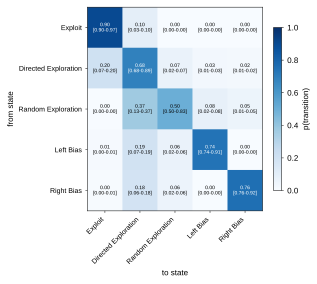

In [7]:
boot_result = sx7.bootstrap_transition_matrix_ci(
    df, STATES_NON_ADAPTING, n_boot=cfg["bootstrap_n"], seed=cfg["bootstrap_seed"]
)
print(f"Bootstrap ({boot_result['n_boot']} resamples of {boot_result['n_animals']} animals):")
print("\nPoint estimate:")
print(boot_result["point_estimate"].round(3))
print("\n95% CI low:")
print(boot_result["ci_low"].round(3))
print("\n95% CI high:")
print(boot_result["ci_high"].round(3))

manifest["bootstrap_transition_matrix"] = {
    "point_estimate": boot_result["point_estimate"].to_dict(),
    "ci_low": boot_result["ci_low"].to_dict(),
    "ci_high": boot_result["ci_high"].to_dict(),
    "n_boot": boot_result["n_boot"],
    "n_animals": boot_result["n_animals"],
}

out_transmat_fig = os.path.join(SUPP_DIR, "RA3_transition_matrix.svg")
plotting.plot_transition_matrix(boot_result["point_estimate"], boot_result["ci_low"], boot_result["ci_high"], out_transmat_fig)
show(out_transmat_fig)
manifest["figures"]["transition_matrix"] = {"path": out_transmat_fig, "tag": "PAPER"}


## 6. RESPONSE MANIFEST

In [8]:
mean_consistency_r = float(np.mean([v["pearson_r_vs_pooled"] for v in consistency.values()]))
top_ttype = top_transition_types.index[0]

response_manifest = {
    "R1-C3_iti_by_state": {
        "sentence": (
            "ITI distribution and post-win-vs-post-loss ITI by behavioral state are reported in full "
            "in iti_by_state above (state_summary / post_win_vs_post_loss)."
        ),
        "state_summary": manifest["iti_by_state"]["state_summary"],
    },
    "R2-4_iti_preceding_transitions": {
        "sentence": (
            f"Mean ITI on trials immediately preceding a behavioral-state transition was "
            f"{iti_transition_result['preceding_transition_mean']:.3f}s, versus "
            f"{iti_transition_result['within_state_mean']:.3f}s on trials that remained within the same "
            f"state (Wilcoxon signed-rank, n={iti_transition_result['n_animals']} animals, "
            f"p={iti_transition_result['wilcoxon_p']:.4g})."
        ),
        "preceding_transition_mean": iti_transition_result["preceding_transition_mean"],
        "within_state_mean": iti_transition_result["within_state_mean"],
        "n_animals": iti_transition_result["n_animals"],
        "wilcoxon_p": iti_transition_result["wilcoxon_p"],
    },
    "R2-4_outcome_sequences_preceding_transitions": {
        "sentence": (
            f"The most common transition type was {top_ttype} (n={int(top_transition_types.iloc[0])}); "
            f"per-transition-type outcome-sequence distributions (last {cfg['history_n']} trials) are in "
            f"transition_type_history above."
        ),
        "top_transition_type": top_ttype,
        "n_top_transition_type": int(top_transition_types.iloc[0]),
    },
    "R2-9_transition_pathway_consistency": {
        "sentence": (
            f"Per-animal transition matrices correlate with the pooled matrix at a mean Pearson r of "
            f"{mean_consistency_r:.3f} across the 5 animals (per-animal r values in "
            f"per_animal_transition_consistency); the pooled matrix's own sampling uncertainty, from a "
            f"{cfg['bootstrap_n']}-replicate animal-cluster bootstrap, is in bootstrap_transition_matrix "
            f"(ci_low/ci_high)."
        ),
        "mean_pearson_r_vs_pooled": mean_consistency_r,
        "per_animal_r": {a: v["pearson_r_vs_pooled"] for a, v in consistency.items()},
    },
}
manifest["response_manifest"] = response_manifest
print(json.dumps(response_manifest, indent=2, default=str))


{
  "R1-C3_iti_by_state": {
    "sentence": "ITI distribution and post-win-vs-post-loss ITI by behavioral state are reported in full in iti_by_state above (state_summary / post_win_vs_post_loss).",
    "state_summary": [
      {
        "Behavioral_State": "Adapting (fast)",
        "mean": 8.923814519865406,
        "sem": 0.8934162801337627,
        "n": 5
      },
      {
        "Behavioral_State": "Adapting (slow)",
        "mean": 10.344941845750691,
        "sem": 1.7551164313324692,
        "n": 5
      },
      {
        "Behavioral_State": "Directed Exploration",
        "mean": 12.160048588116036,
        "sem": 1.7464452727550022,
        "n": 5
      },
      {
        "Behavioral_State": "Exploit",
        "mean": 6.800382042175552,
        "sem": 0.9790324692882922,
        "n": 5
      },
      {
        "Behavioral_State": "Left Bias",
        "mean": 10.435732851597004,
        "sem": 2.8968109114879526,
        "n": 5
      },
      {
        "Behavioral_State": "Ran

In [9]:
manifest_path = os.path.join(MANIFEST_DIR, "RA3.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")



Saved values manifest: ../../outputs/values_manifests/RA3.json
